# 📈 Financial Freedom Machine Learning


In [1]:
#ngimpor yuk
import warnings
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm             import SVC
from sklearn.metrics         import (accuracy_score, precision_score,
                                     recall_score, confusion_matrix,
                                     ConfusionMatrixDisplay)
from sklearn.preprocessing   import StandardScaler

from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier

matplotlib.rcParams.update({
    "figure.dpi"    : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"     : True,
    "grid.alpha"    : 0.3,
})

print("✅ All libraries imported successfully")


✅ All libraries imported successfully


## 1 · Data Loading

In [6]:
#load data 
CSV_PATH = "data03.csv"

df = pd.read_csv(CSV_PATH)
#grammar si
df.columns = df.columns.str.strip().str.lower()

# sort ascending bedasarkan data tanggal
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

# drop data yang gapunya olhcv
df.dropna(subset=["open","high","low","close","volume"], inplace=True)

print(f"Rows   : {len(df):,}")
print(f"Date range: {df['date'].min().date()}  →  {df['date'].max().date()}")
df.head()


Rows   : 4,110
Date range: 2010-01-04  →  2026-05-07


,date,close,high,low,open,volume
0,2010-01-04,1117.699951,1122.300049,1097.099976,1117.699951,184
1,2010-01-05,1118.099976,1126.500000,1115.000000,1118.099976,53
2,2010-01-06,1135.900024,1139.199951,1120.699951,1135.900024,363
3,2010-01-07,1133.099976,1133.099976,1129.199951,1133.099976,56
4,2010-01-08,1138.199951,1138.199951,1122.699951,1138.199951,54


## 2 · Feature Engineering

In [7]:
#beberapa fungsi buat fitur baru
df["return"]     = df["close"].pct_change()               # daily return
df["range"]      = df["high"] - df["low"]                 # intraday range
df["ma10"]       = df["close"].rolling(10).mean()         # 10-day moving avg
df["ma50"]       = df["close"].rolling(50).mean()         # 50-day moving avg
df["volatility"] = df["close"].rolling(10).std()          # 10-day volatility
#cherry on top gf
df["ma10_ma50_diff"] = df["ma10"] - df["ma50"]            # MA crossover signal
df["vol_ma10"]       = df["volume"].rolling(10).mean()    # volume trend
df["price_ma10"]     = df["close"] / df["ma10"] - 1      # price deviation from MA

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Rows after feature engineering: {len(df):,}")
print("\nFeature columns:")
FEATURE_COLS = ["return","range","ma10","ma50","volatility",
                "ma10_ma50_diff","vol_ma10","price_ma10"]
print(FEATURE_COLS)
df[FEATURE_COLS].describe().round(4)


Rows after feature engineering: 4,061

Feature columns:
['return', 'range', 'ma10', 'ma50', 'volatility', 'ma10_ma50_diff', 'vol_ma10', 'price_ma10']


,return,range,ma10,ma50,volatility,ma10_ma50_diff,vol_ma10,price_ma10
count,4061.0000,4061.0000,4061.0000,4061.0000,4061.0000,4061.0000,4061.0000,4061.0000
mean,0.0004,19.4195,1734.4366,1716.6678,22.4231,17.7689,5203.6364,0.0016
std,0.0107,26.8512,731.2792,699.4515,23.6555,71.9058,9797.4771,0.0172
min,-0.1137,0.0000,1066.7700,1076.7640,2.1406,-406.0160,2.6000,-0.1164
25%,-0.0046,7.7000,1275.7800,1277.0840,11.0852,-20.5860,172.6000,-0.0081
50%,0.0005,13.7999,1538.6900,1521.6220,15.8691,5.7460,377.0000,0.0017
75%,0.0060,23.1001,1849.4900,1852.7860,24.7033,45.4160,2206.1000,0.0120
max,0.0608,740.5000,5170.7300,4951.8080,296.3697,512.0360,44962.5000,0.0871


## 3. Prediksi besok


In [8]:
# ── 3. TARGET VARIABLE ────────────────────────────────────────────────────────
# target = 1  → besok -> harga naik
# target = 0  → harga tetap atau turun
df["target"] = (df["close"].shift(-1) > df["close"]).astype(int)
#drop data yang gapunya target (biasanya baris terakhir)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
up   = df["target"].sum()
down = len(df) - up
print(f"Class distribution:  ↑ UP={up} ({up/len(df)*100:.1f}%)  |  ↓ DOWN={down} ({down/len(df)*100:.1f}%)")


Class distribution:  ↑ UP=2147 (52.9%)  |  ↓ DOWN=1914 (47.1%)


## 4 · Train / Test Split (Time-Series)

In [9]:
#training data dan testing data
# Kita pakai 80% data untuk training, sisanya 20% untuk testing
split_idx = int(len(df) * 0.80)

X = df[FEATURE_COLS]
y = df["target"]

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

dates_test = df["date"].iloc[split_idx:].reset_index(drop=True)
close_test = df["close"].iloc[split_idx:].reset_index(drop=True)

print(f"Train: {len(X_train):,} rows  ({df['date'].iloc[0].date()} → {df['date'].iloc[split_idx-1].date()})")
print(f"Test : {len(X_test):,}  rows  ({df['date'].iloc[split_idx].date()} → {df['date'].iloc[-1].date()})")

#scale fitur biar model ga bingung sama skala yang beda-beda
scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


Train: 3,248 rows  (2010-03-16 → 2023-02-10)
Test : 813  rows  (2023-02-13 → 2026-05-07)


## 5 · Model Training

In [10]:
#latih semua model 

models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree"       : DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest"       : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting"   : GradientBoostingClassifier(n_estimators=200, random_state=42),
    "XGBoost"             : XGBClassifier(n_estimators=200, use_label_encoder=False,
                                          eval_metric="logloss", random_state=42),
    "LightGBM"            : LGBMClassifier(n_estimators=200, random_state=42, verbose=-1),
    "SVM"                 : SVC(kernel="rbf", probability=True, random_state=42),
}

# model yang butuh fitur diskalakan (LR, SVM) biar ga bingung sama skala yang beda-beda
SCALED_MODELS = {"Logistic Regression", "SVM"}

predictions = {}   # nyimpen prediksi test
results     = []   # nyimpen hasil metrik

for name, model in models.items():
    Xtr = X_train_sc if name in SCALED_MODELS else X_train
    Xte = X_test_sc  if name in SCALED_MODELS else X_test

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    predictions[name] = y_pred

    acc  = accuracy_score (y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score   (y_test, y_pred, zero_division=0)

    results.append({"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec})
    print(f"{name:<22}  acc={acc:.4f}  prec={prec:.4f}  rec={rec:.4f}")

print("\n✅ All models trained.")


Logistic Regression     acc=0.5658  prec=0.5661  rec=0.9604
Decision Tree           acc=0.5498  prec=0.5748  rec=0.7516
Random Forest           acc=0.4539  prec=0.5364  rec=0.1780
Gradient Boosting       acc=0.4613  prec=0.5362  rec=0.2769
XGBoost                 acc=0.4551  prec=0.5385  rec=0.1846
LightGBM                acc=0.4822  prec=0.5825  rec=0.2637
SVM                     acc=0.5203  prec=0.5479  rec=0.8176

✅ All models trained.


## 6 · Model Comparison

In [11]:
#compare model
results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
results_df.index += 1   # 1-based rank
#simpen ke csv
results_df.to_csv("comparison_results.csv", index=True)

print("Model ranking (by Accuracy)\n")
print(results_df.to_string())
print("\n✅ Saved → comparison_results.csv")

Model ranking (by Accuracy)

                 Model  Accuracy  Precision    Recall
1  Logistic Regression  0.565806   0.566062  0.960440
2        Decision Tree  0.549815   0.574790  0.751648
3                  SVM  0.520295   0.547865  0.817582
4             LightGBM  0.482165   0.582524  0.263736
5    Gradient Boosting  0.461255   0.536170  0.276923
6              XGBoost  0.455105   0.538462  0.184615
7        Random Forest  0.453875   0.536424  0.178022

✅ Saved → comparison_results.csv


## 7 · Confusion Matrices for All Models

## 8 · Per-Model Prediction vs Actual (Test Period)

  Saved → logistic_regression_prediction.png


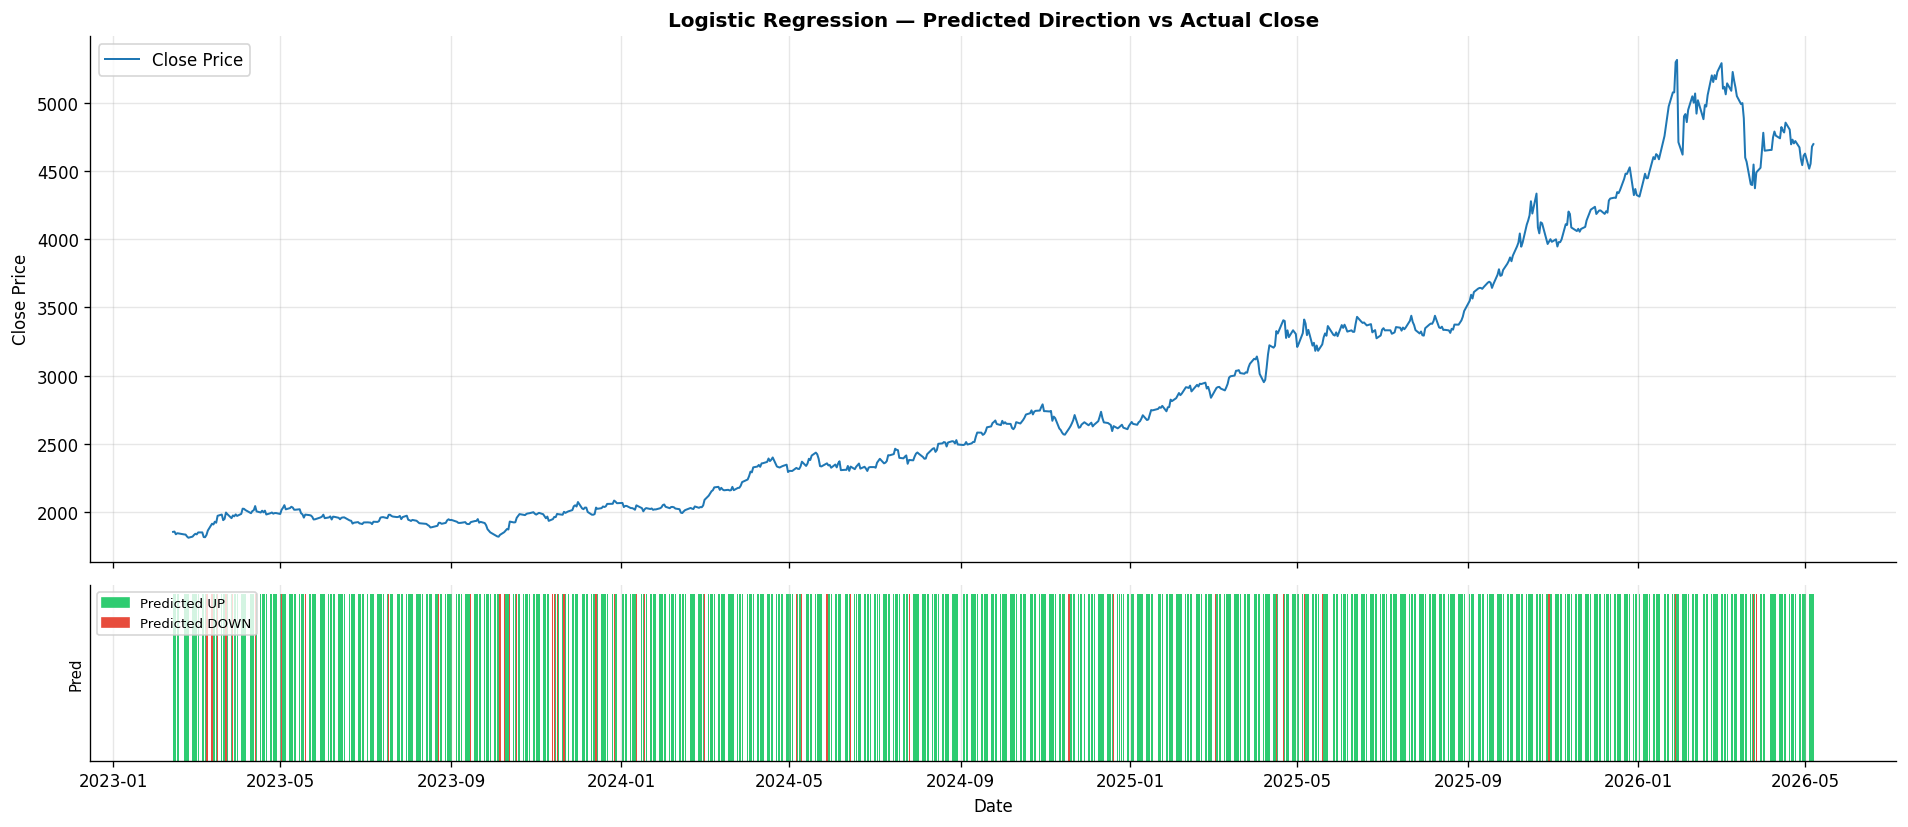

  Saved → decision_tree_prediction.png


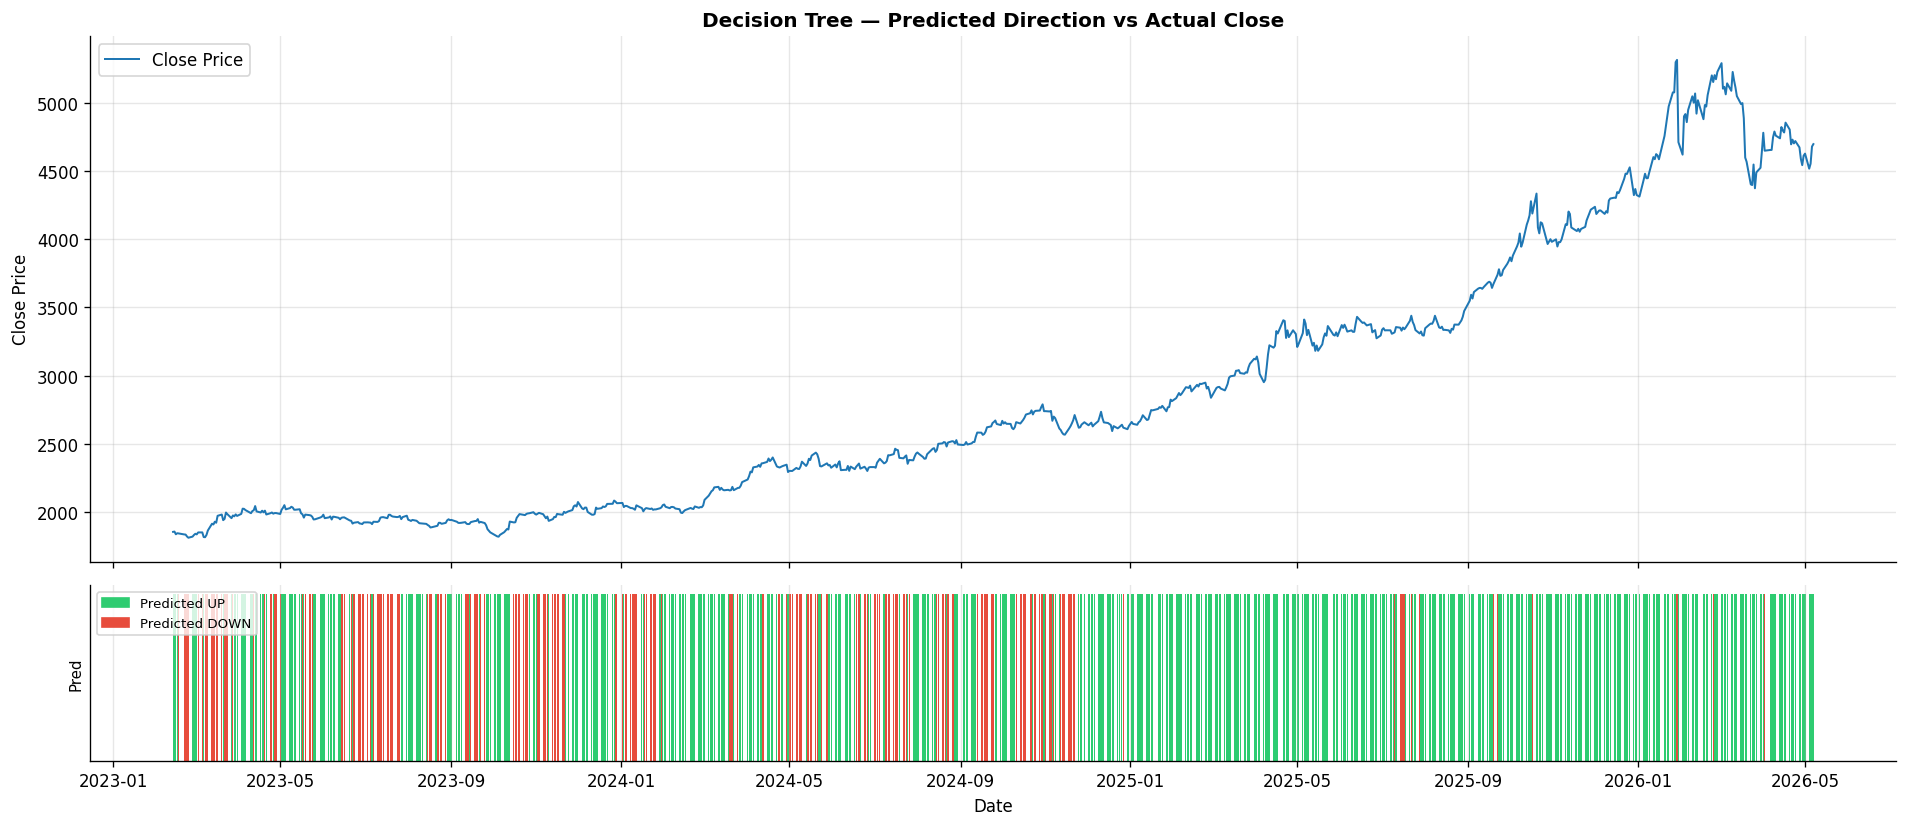

  Saved → random_forest_prediction.png


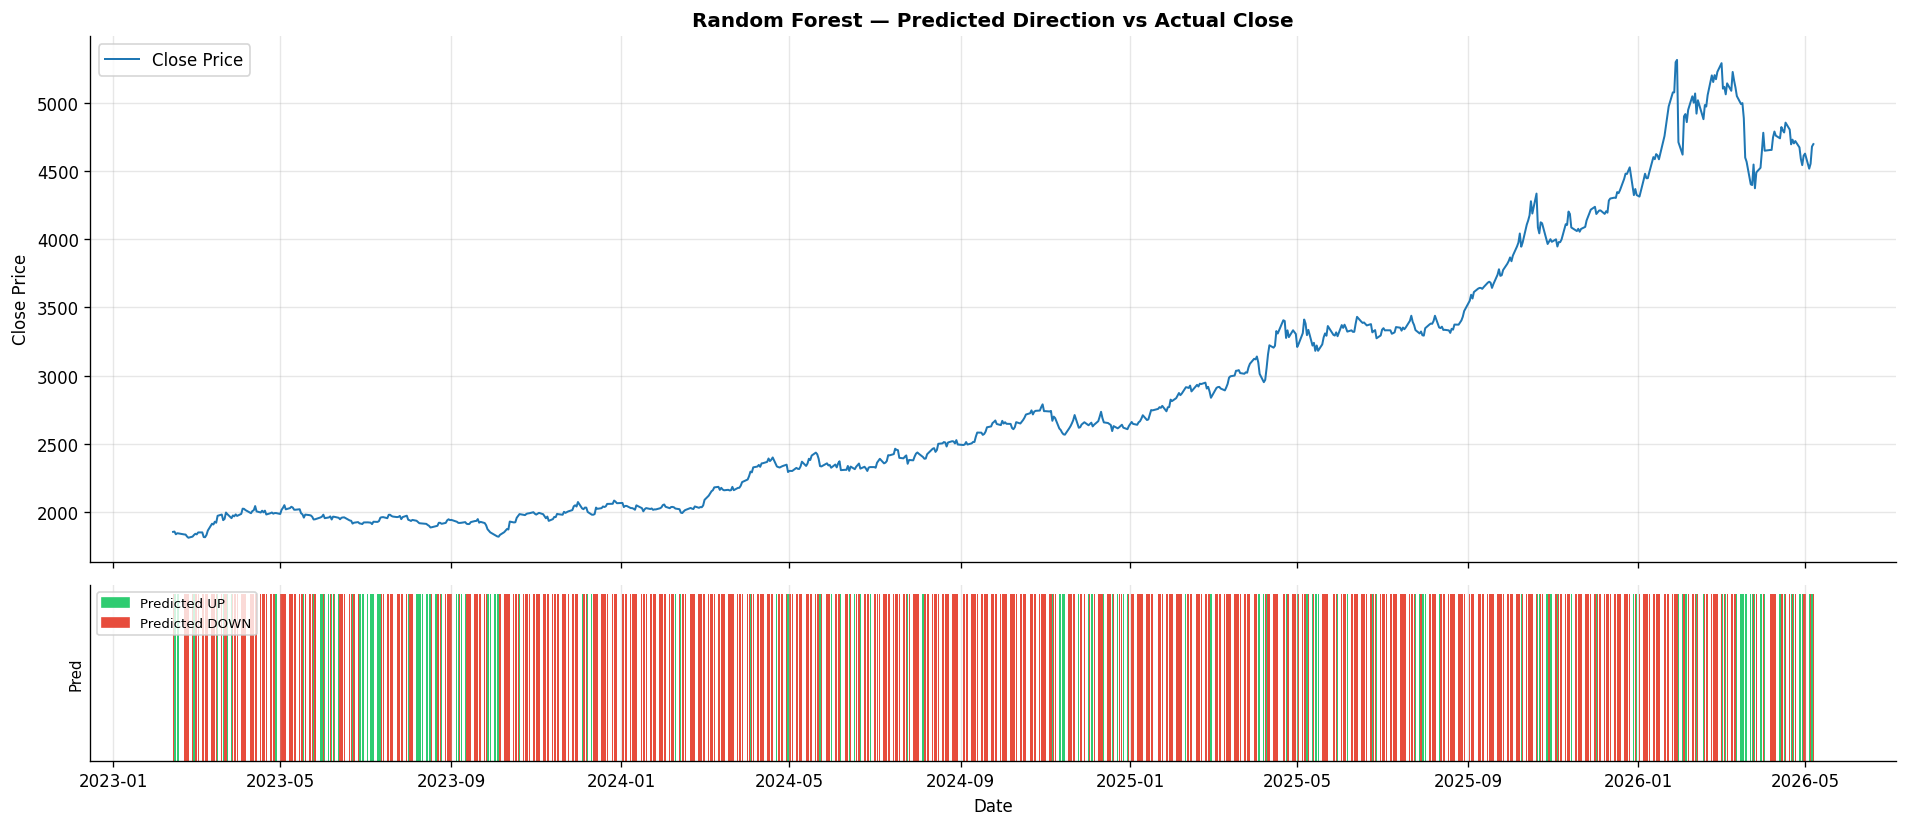

  Saved → gradient_boosting_prediction.png


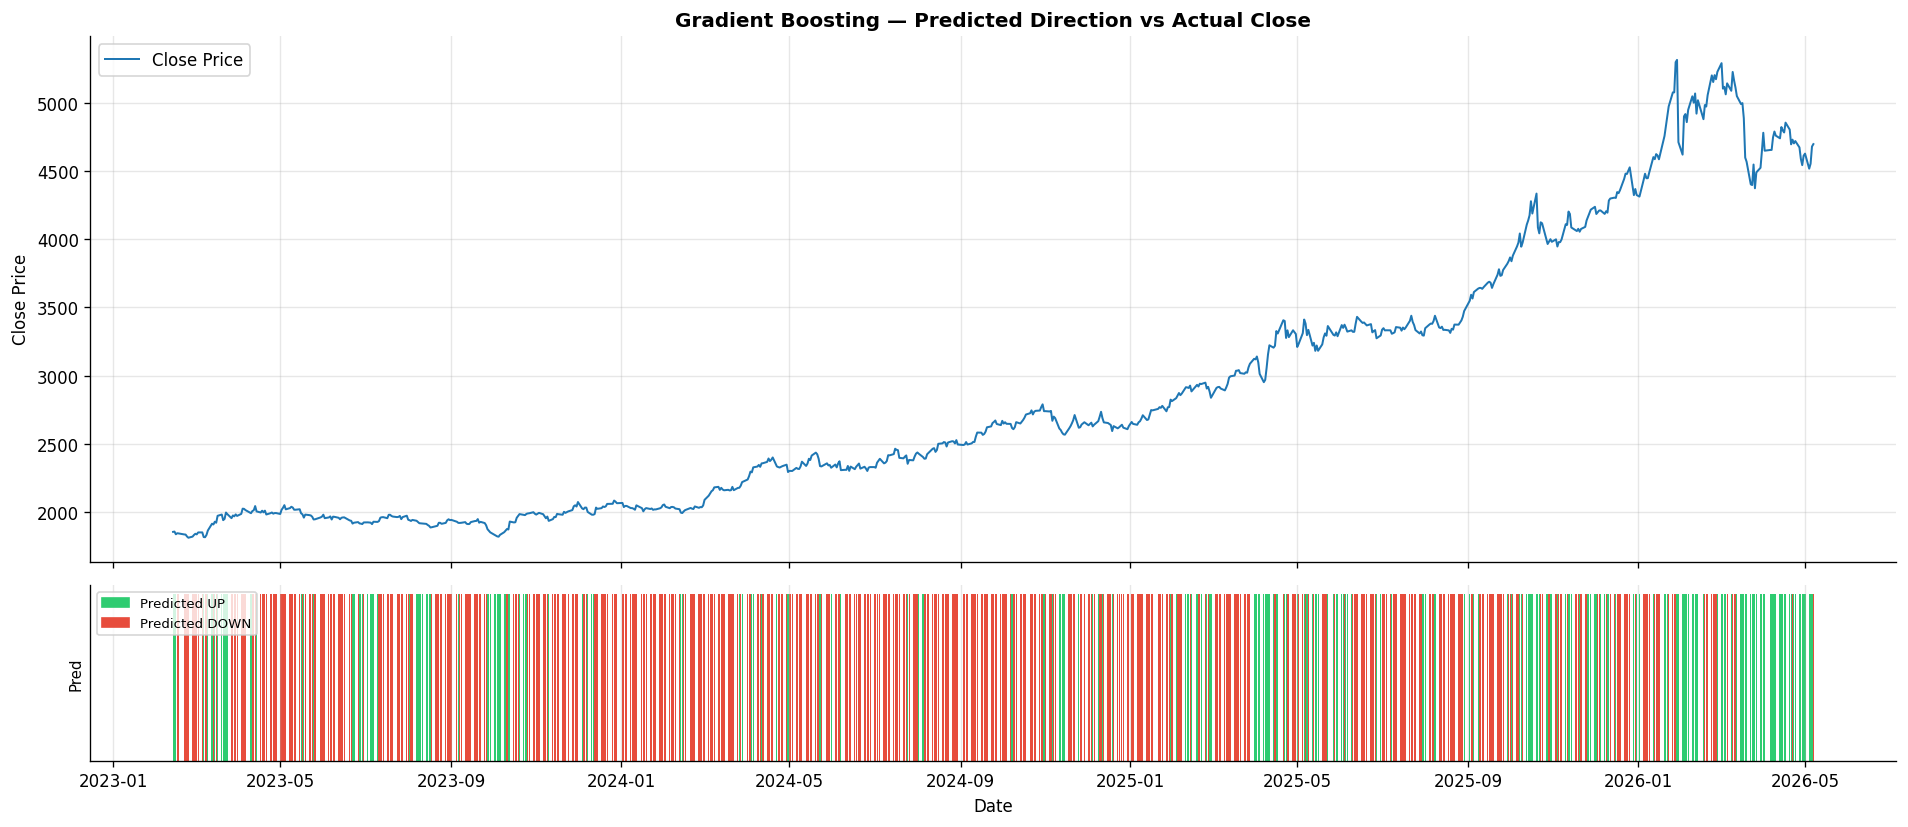

  Saved → xgboost_prediction.png


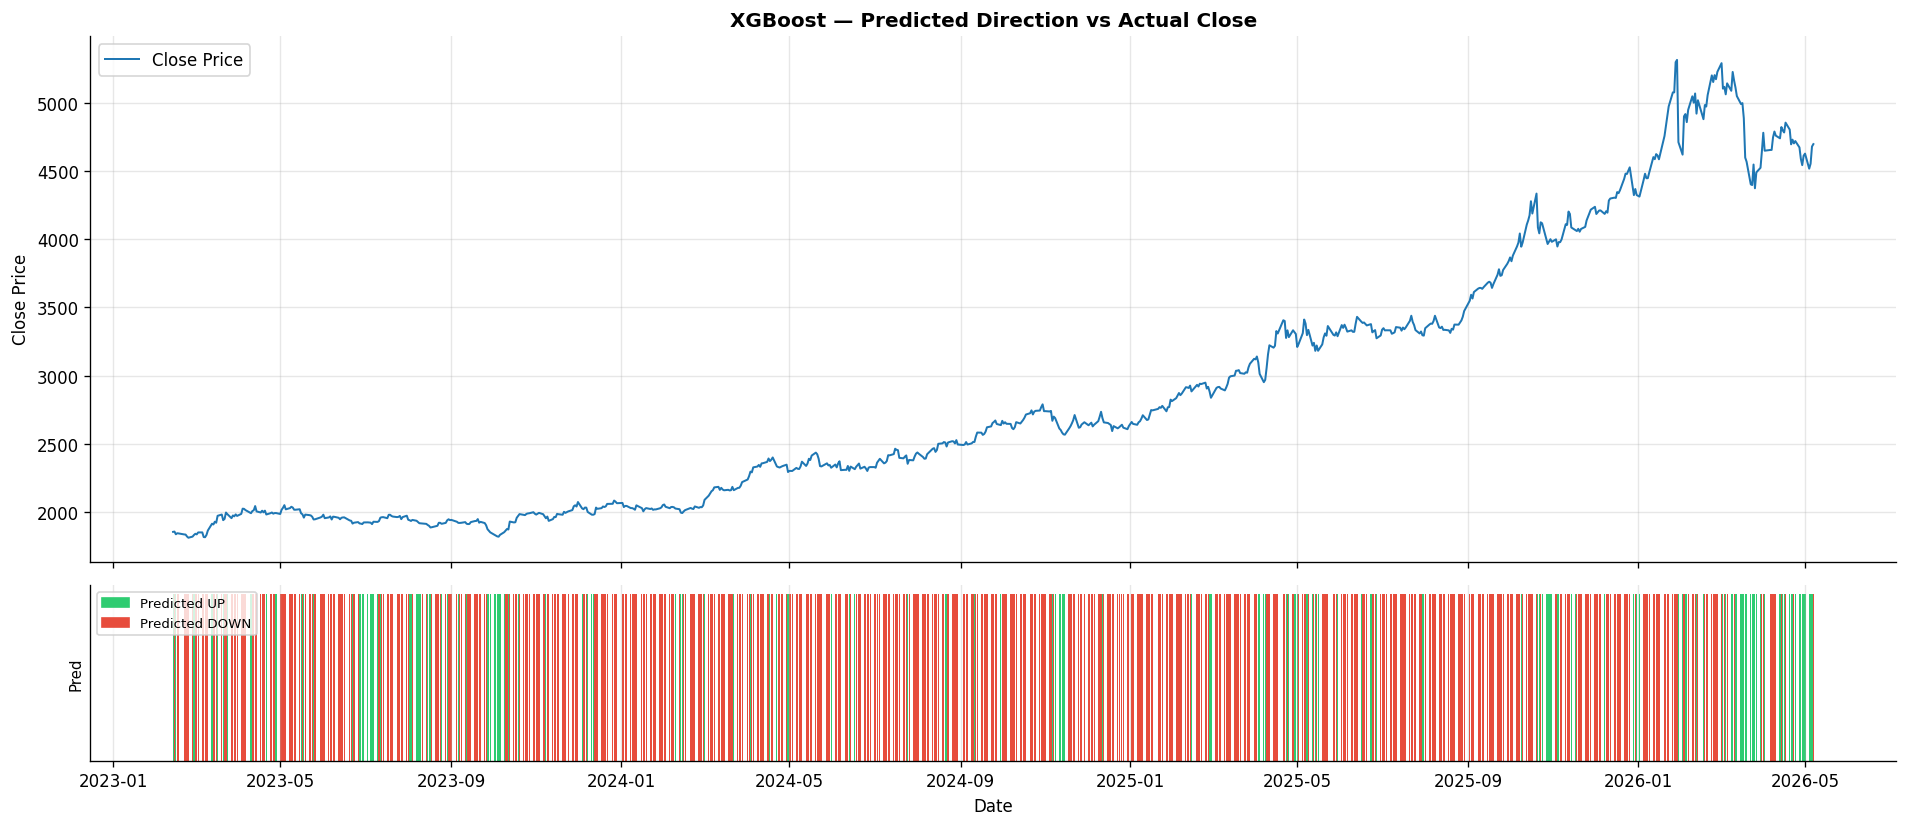

  Saved → lightgbm_prediction.png


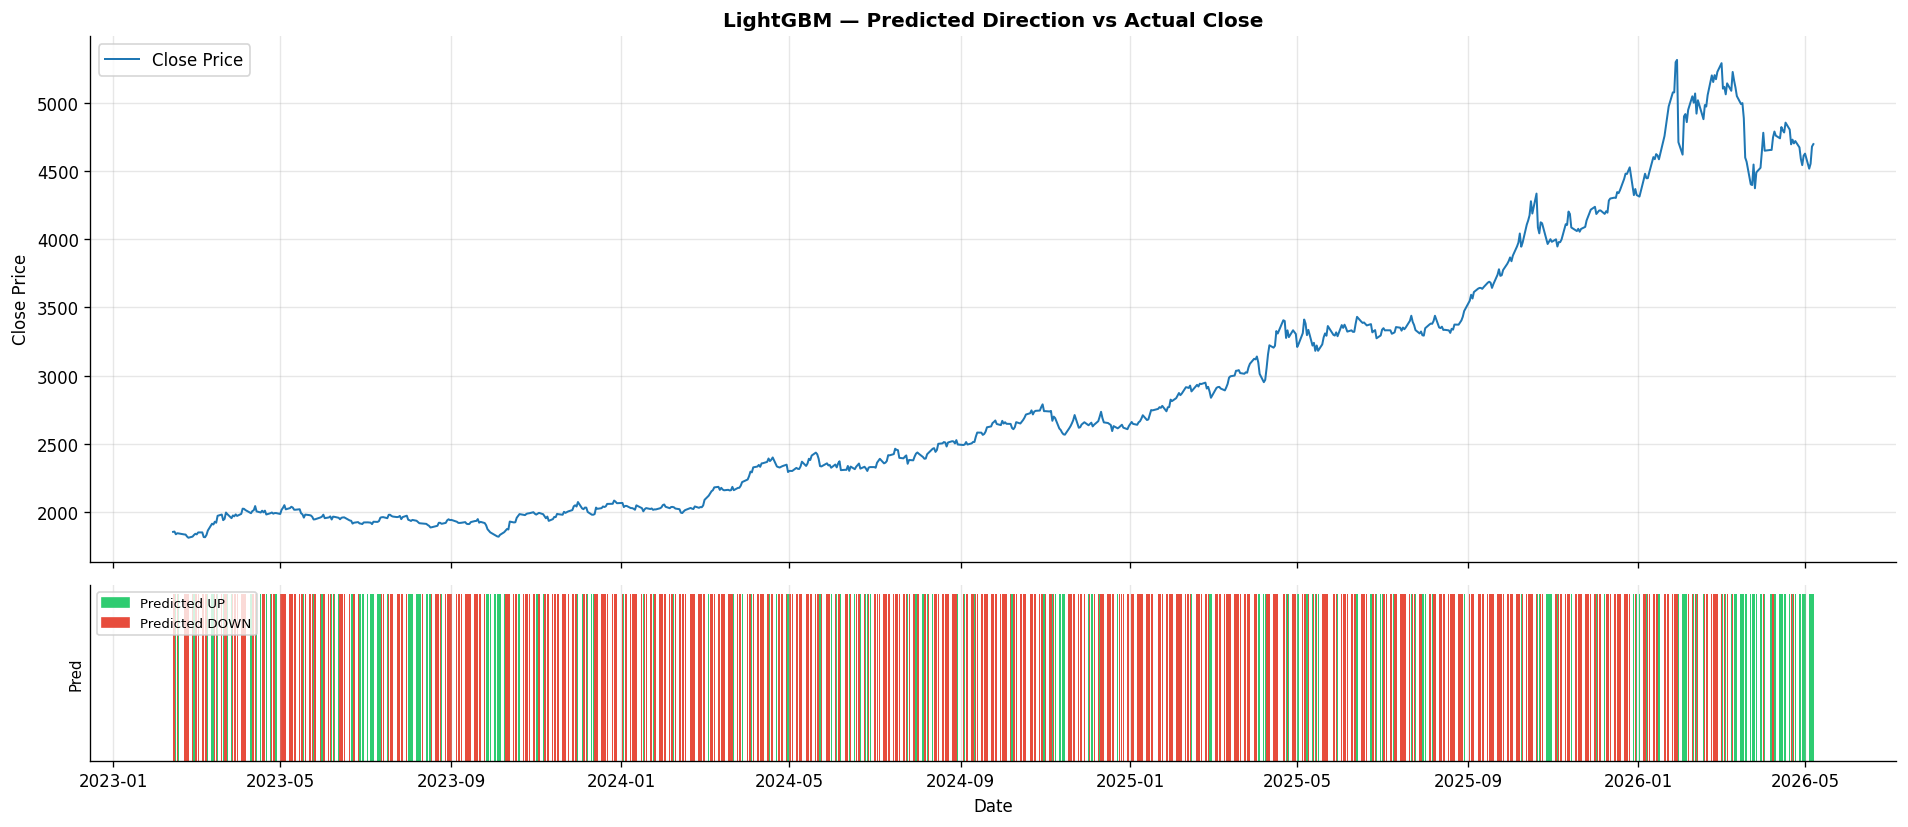

  Saved → svm_prediction.png


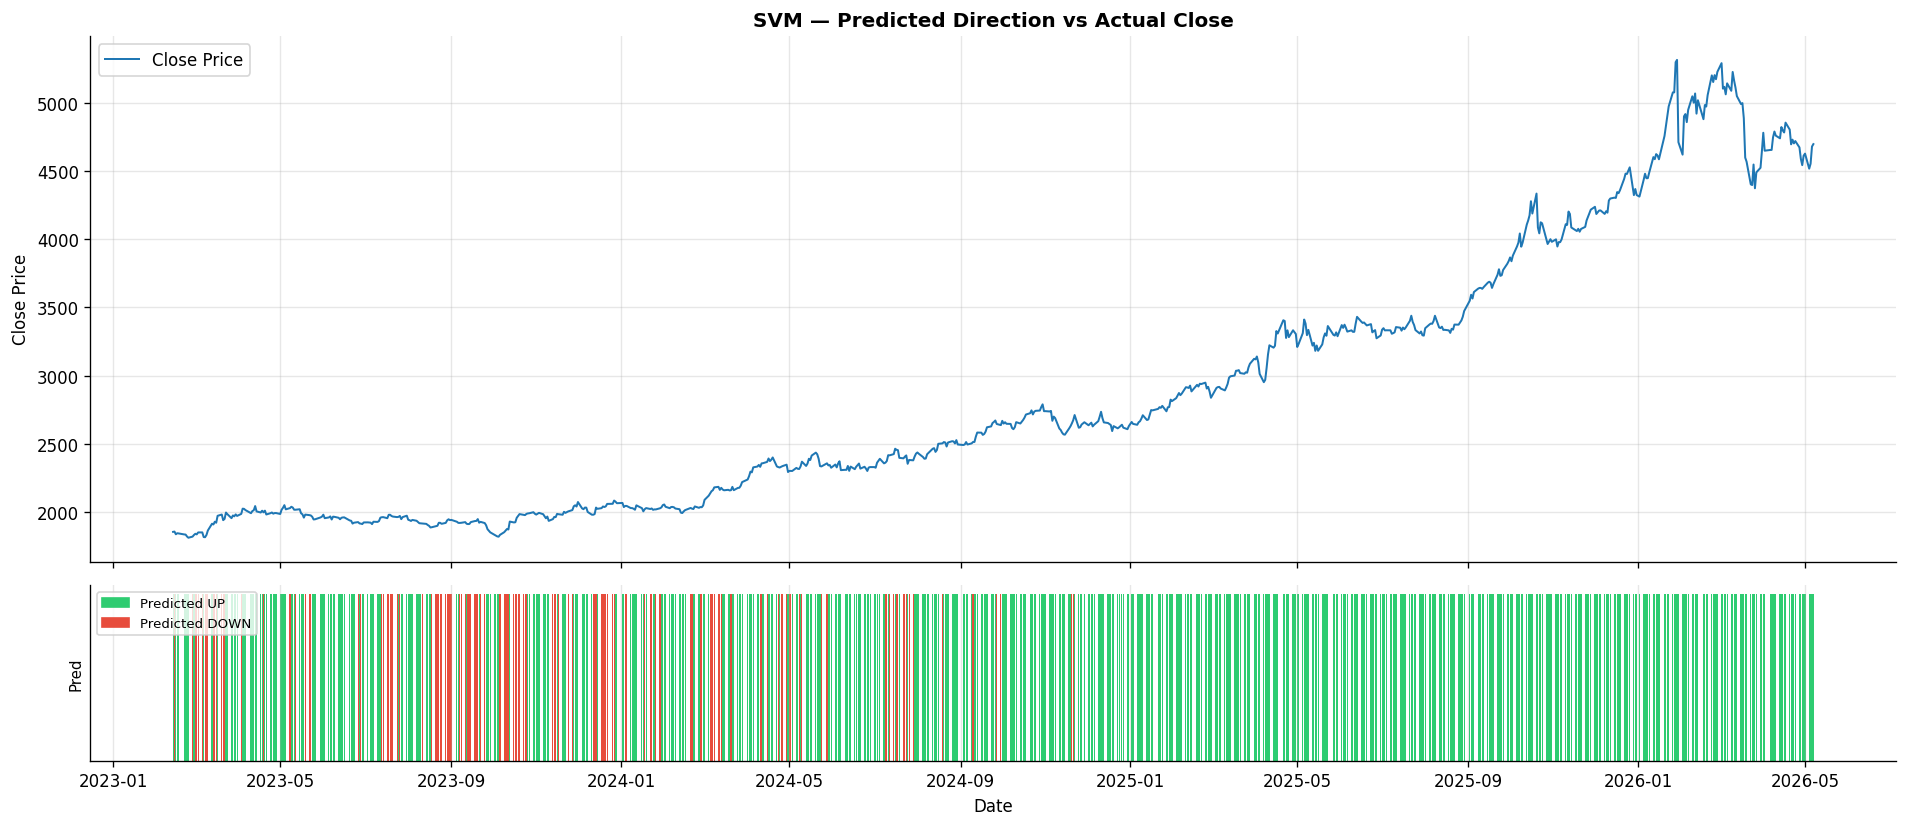

In [13]:

#plot prediksi per model
# Untuk setiap model kita plot:
#   • Harga Close aktual (garis)
#   • Garis vertikal berwarna HIJAU (prediksi NAIK) atau MERAH (prediksi TURUN)

def plot_model_prediction(name, y_pred, dates, close, save=True):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 7), sharex=True,
                                   gridspec_kw={"height_ratios": [3, 1]})

    # ── top: close price
    ax1.plot(dates, close, color="#1f77b4", lw=1.2, label="Close Price")
    ax1.set_ylabel("Close Price", fontsize=10)
    ax1.set_title(f"{name} — Predicted Direction vs Actual Close", fontsize=12, fontweight="bold")
    ax1.legend(loc="upper left")

    # ── bottom: predicted direction as coloured bars
    colors = ["#e74c3c" if p == 0 else "#2ecc71" for p in y_pred]
    ax2.bar(dates, [1]*len(dates), color=colors, width=0.8, align="center")
    ax2.set_yticks([])
    ax2.set_ylabel("Pred", fontsize=9)

    up_patch   = mpatches.Patch(color="#2ecc71", label="Predicted UP")
    down_patch = mpatches.Patch(color="#e74c3c", label="Predicted DOWN")
    ax2.legend(handles=[up_patch, down_patch], loc="upper left", fontsize=8)

    plt.xlabel("Date", fontsize=10)
    plt.tight_layout()

    if save:
        fname = name.lower().replace(" ","_") + "_prediction.png"
        plt.savefig(fname, bbox_inches="tight")
        print(f"  Saved → {fname}")
    plt.show()

for name, y_pred in predictions.items():
    plot_model_prediction(name, y_pred, dates_test, close_test)


## 9 · Final Comparison Chart — Top 3 Models

Top 3 models: ['Logistic Regression', 'Decision Tree', 'SVM']


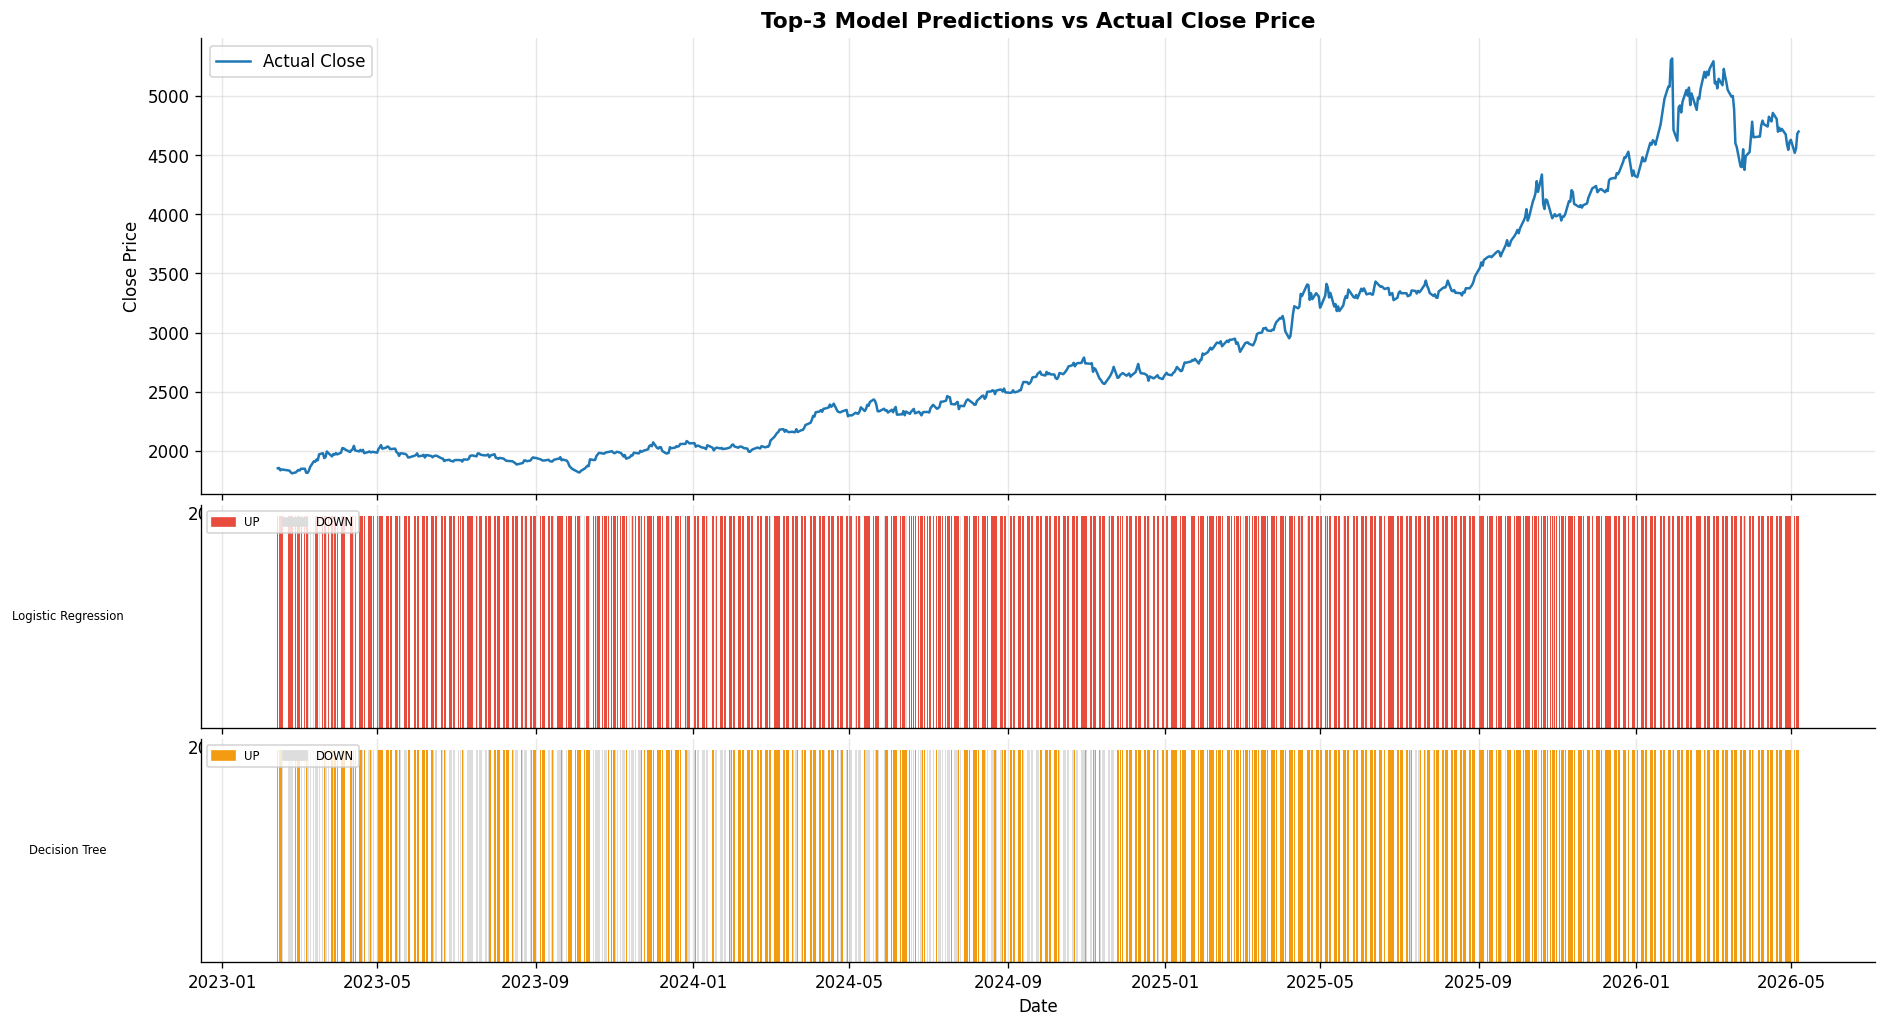

✅ Saved → comparison_chart.png


In [14]:
#final komper maseh

top3 = results_df["Model"].head(3).tolist()
print("Top 3 models:", top3)

palette = ["#e74c3c", "#f39c12", "#9b59b6"]   #warna 

fig = plt.figure(figsize=(18, 10))
gs  = GridSpec(4, 1, hspace=0.05)

ax_price  = fig.add_subplot(gs[0:2])
ax_models = [fig.add_subplot(gs[i+2], sharex=ax_price) for i in range(2)]
ax_price.plot(dates_test, close_test, color="#1f77b4", lw=1.5, label="Actual Close")
ax_price.set_ylabel("Close Price", fontsize=10)
ax_price.set_title("Top-3 Model Predictions vs Actual Close Price", fontsize=13, fontweight="bold")
ax_price.legend(loc="upper left")
for ax, mname, color in zip(ax_models, top3[:2], palette[:2]):
    y_pred = predictions[mname]
    bar_colors = [color if p == 1 else "#dddddd" for p in y_pred]
    ax.bar(dates_test, [1]*len(dates_test), color=bar_colors, width=0.8)
    ax.set_yticks([])
    ax.set_ylabel(mname, fontsize=7, rotation=0, labelpad=80, va="center")
    up_p = mpatches.Patch(color=color,     label="UP")
    dn_p = mpatches.Patch(color="#dddddd", label="DOWN")
    ax.legend(handles=[up_p, dn_p], loc="upper left", fontsize=7, ncol=2)

plt.xlabel("Date", fontsize=10)
plt.savefig("comparison_chart.png", bbox_inches="tight")
plt.show()
print("✅ Saved → comparison_chart.png")


## 10 · Accuracy Bar Chart

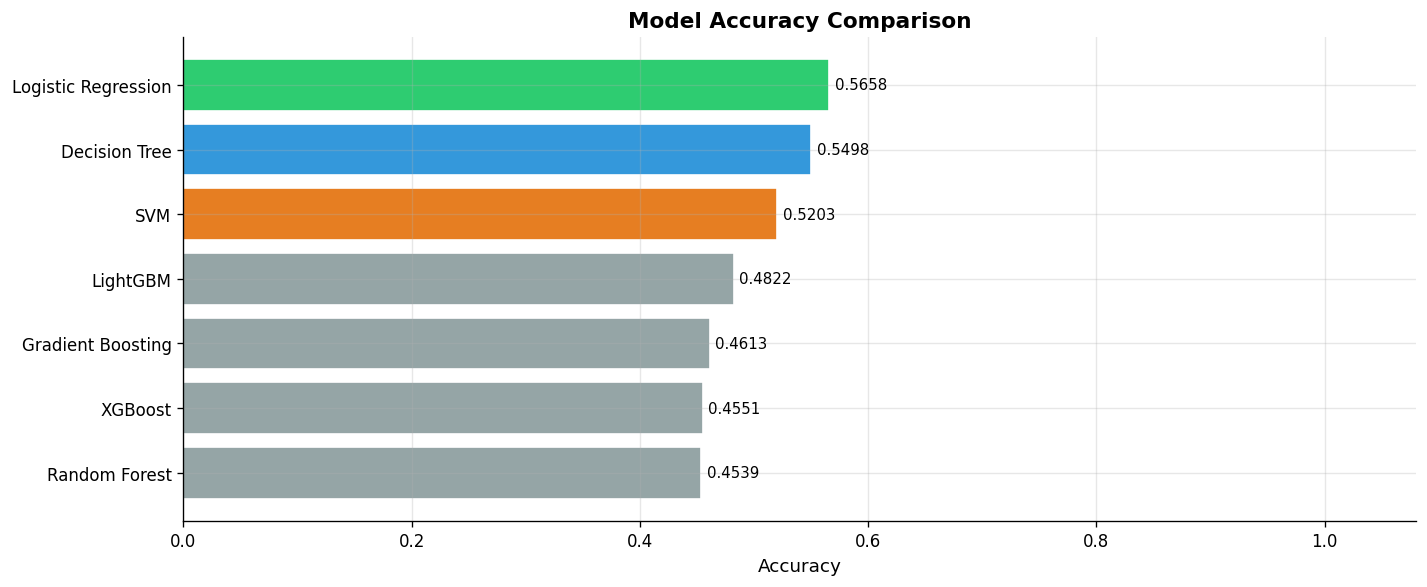

✅ Saved → accuracy_comparison.png


In [15]:
# akurasi per model dalam bentuk bar chart

fig, ax = plt.subplots(figsize=(12, 5))

bar_colors = ["#2ecc71" if i == 0 else "#3498db" if i == 1 else "#e67e22" if i == 2 else "#95a5a6"
              for i in range(len(results_df))]

bars = ax.barh(results_df["Model"], results_df["Accuracy"], color=bar_colors, edgecolor="white")
ax.set_xlabel("Accuracy", fontsize=11)
ax.set_title("Model Accuracy Comparison", fontsize=13, fontweight="bold")
ax.set_xlim(0, 1.08)

for bar, val in zip(bars, results_df["Accuracy"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9)

ax.invert_yaxis()
plt.tight_layout()
plt.savefig("accuracy_comparison.png", bbox_inches="tight")
plt.show()
print("✅ Saved → accuracy_comparison.png")


## 11 · Metrics Heatmap

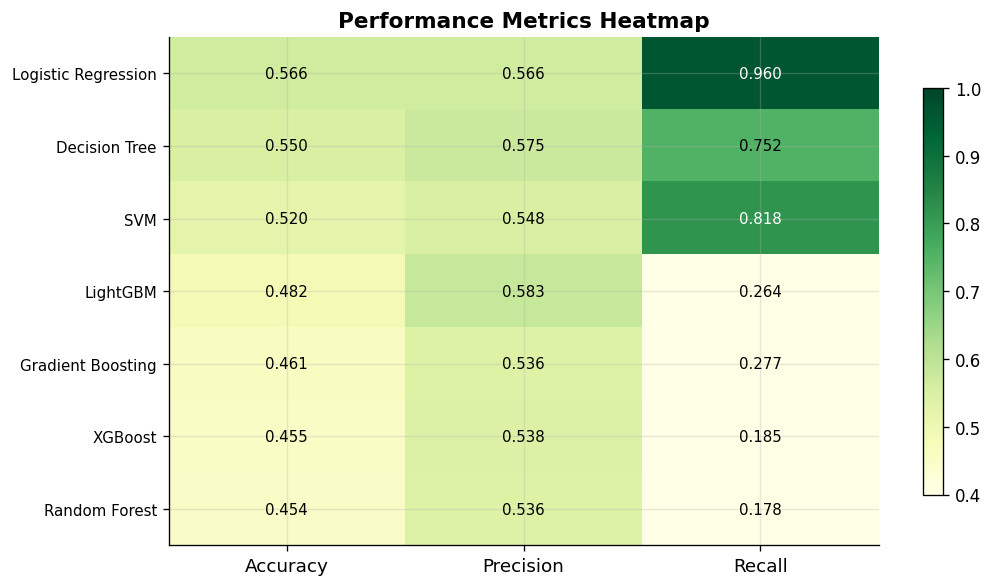

✅ Saved → metrics_heatmap.png


In [16]:
#itulah pokoknya

metric_data = results_df.set_index("Model")[["Accuracy","Precision","Recall"]]

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(metric_data.values, cmap="YlGn", aspect="auto", vmin=0.4, vmax=1.0)
plt.colorbar(im, ax=ax, shrink=0.8)

ax.set_xticks(range(3));  ax.set_xticklabels(metric_data.columns, fontsize=11)
ax.set_yticks(range(len(metric_data))); ax.set_yticklabels(metric_data.index, fontsize=9)
ax.set_title("Performance Metrics Heatmap", fontsize=13, fontweight="bold")

for i in range(len(metric_data)):
    for j in range(3):
        ax.text(j, i, f"{metric_data.values[i,j]:.3f}",
                ha="center", va="center", fontsize=9,
                color="black" if metric_data.values[i,j] < 0.8 else "white")

plt.tight_layout()
plt.savefig("metrics_heatmap.png", bbox_inches="tight")
plt.show()
print("✅ Saved → metrics_heatmap.png")


## 12 · Future 30-Day Direction Prediction

Best model: Logistic Regression


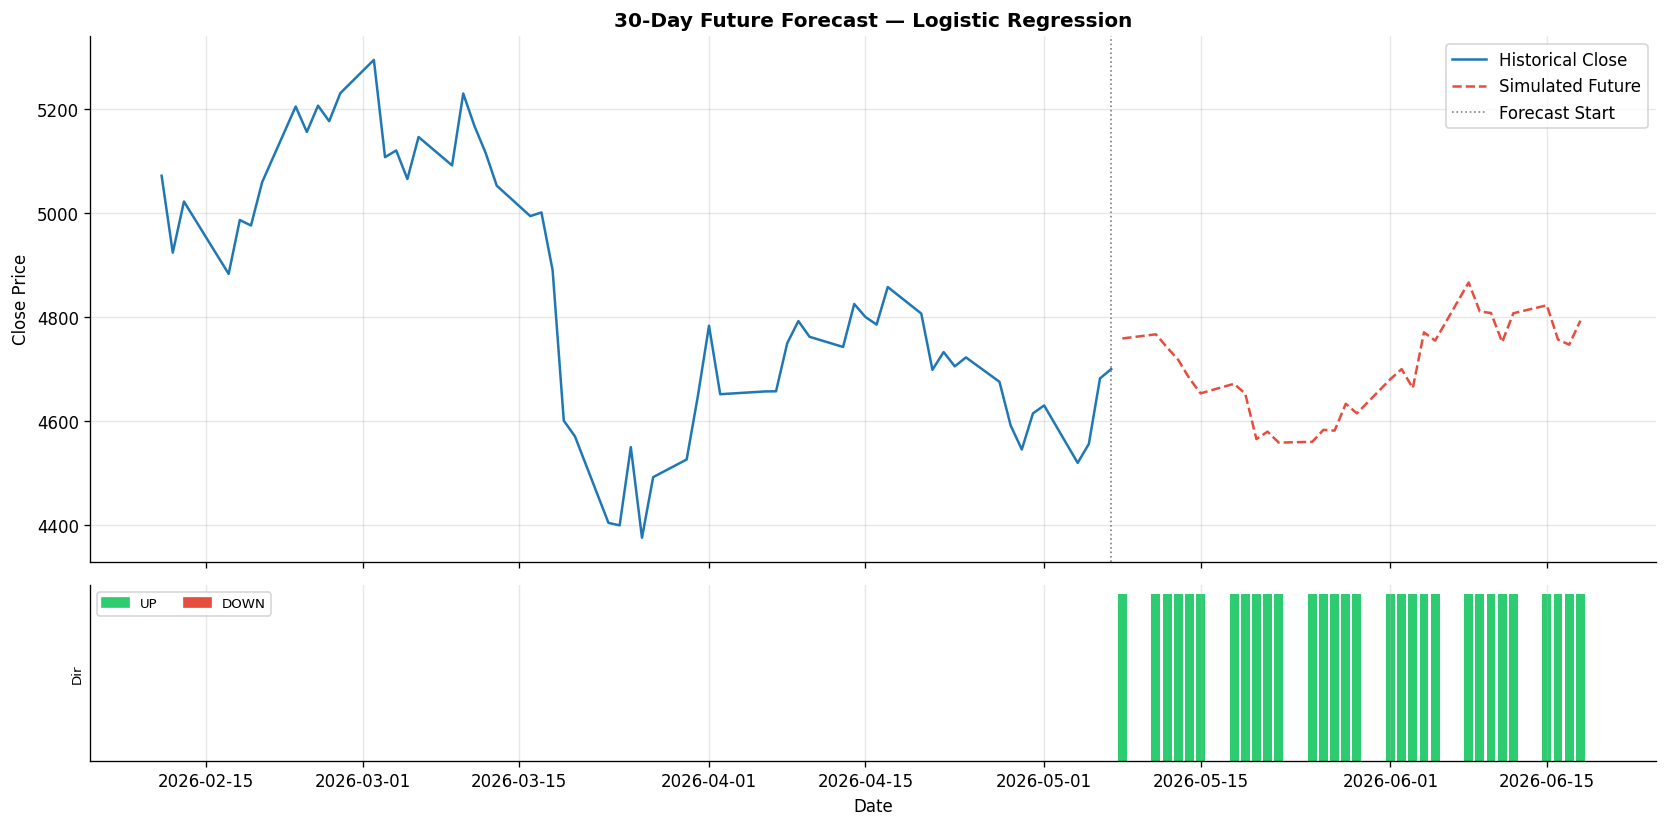


30-Day Forecast Summary:  ↑ UP=30  |  ↓ DOWN=0
✅ Saved → future_30day_prediction.png


In [17]:
#PREDIKSI ARAH 30 HARI KE DEPAN JINGG CANGGIH
# Strategi: prediksi arah harga hari berikutnya secara iteratif menggunakan fitur terakhir yang diketahui.
# Menggunakan model TERBAIK (peringkat teratas).

BEST_MODEL_NAME = results_df["Model"].iloc[0]
best_model      = models[BEST_MODEL_NAME]
print(f"Best model: {BEST_MODEL_NAME}")

FUTURE_DAYS = 30
last_row = df.iloc[-1].copy()
simulated_close = last_row["close"]
last_date       = last_row["date"]

future_dates      = []
future_directions = []
future_closes     = []
rolling_closes = list(df["close"].tail(50)) 
for d in range(FUTURE_DAYS):
    rc = np.array(rolling_closes)
    feat = {
        "return"       : (rc[-1] - rc[-2]) / rc[-2],
        "range"        : last_row["high"] - last_row["low"],   
        "ma10"         : rc[-10:].mean(),
        "ma50"         : rc[-50:].mean(),
        "volatility"   : rc[-10:].std(),
        "ma10_ma50_diff": rc[-10:].mean() - rc[-50:].mean(),
        "vol_ma10"     : last_row["vol_ma10"],                 
        "price_ma10"   : rc[-1] / rc[-10:].mean() - 1,
    }
    X_fut = pd.DataFrame([feat])[FEATURE_COLS]

    if BEST_MODEL_NAME in SCALED_MODELS:
        X_fut = scaler.transform(X_fut)

    direction = best_model.predict(X_fut)[0]

    next_date = last_date + pd.Timedelta(days=1)
    #skip hari libur (istirahat jir capek
    while next_date.weekday() >= 5:
        next_date += pd.Timedelta(days=1)
    pct_change = np.random.normal(loc=0.001 if direction==1 else -0.001, scale=0.01)
    next_close = simulated_close * (1 + pct_change)

    future_dates.append(next_date)
    future_directions.append(direction)
    future_closes.append(next_close)

    rolling_closes.append(next_close)
    rolling_closes.pop(0)
    simulated_close = next_close
    last_date       = next_date

#Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                               gridspec_kw={"height_ratios":[3,1]})
hist_tail = df.tail(60)
ax1.plot(hist_tail["date"], hist_tail["close"], color="#1f77b4", lw=1.5, label="Historical Close")
ax1.plot(future_dates, future_closes, color="#e74c3c", lw=1.5, ls="--", label="Simulated Future")
ax1.axvline(df["date"].iloc[-1], color="gray", ls=":", lw=1, label="Forecast Start")
ax1.set_ylabel("Close Price")
ax1.set_title(f"30-Day Future Forecast — {BEST_MODEL_NAME}", fontsize=12, fontweight="bold")
ax1.legend()
colors = ["#2ecc71" if d==1 else "#e74c3c" for d in future_directions]
ax2.bar(future_dates, [1]*FUTURE_DAYS, color=colors, width=0.8)
ax2.set_yticks([])
ax2.set_ylabel("Dir", fontsize=8)
up_p = mpatches.Patch(color="#2ecc71", label="UP"); dn_p = mpatches.Patch(color="#e74c3c", label="DOWN")
ax2.legend(handles=[up_p,dn_p], loc="upper left", fontsize=8, ncol=2)
ax2.set_xlabel("Date")
plt.tight_layout()
plt.savefig("future_30day_prediction.png", bbox_inches="tight")
plt.show()
n_up = sum(future_directions); n_dn = FUTURE_DAYS - n_up
print(f"\n30-Day Forecast Summary:  ↑ UP={n_up}  |  ↓ DOWN={n_dn}")
print("✅ Saved → future_30day_prediction.png")


## 13 · Output Files Summary

In [18]:
#list semua file output
import os, glob

output_files = sorted(glob.glob("*.png") + glob.glob("*.csv"))

print("Generated output files:\n")
for f in output_files:
    size = os.path.getsize(f)
    print(f"  📄 {f:<45}  ({size/1024:.1f} KB)")

print(f"\n✅ Pipeline complete! Best model: {BEST_MODEL_NAME} (Accuracy={results_df['Accuracy'].iloc[0]:.4f})")


Generated output files:

  📄 accuracy_comparison.png                        (37.3 KB)
  📄 comparison_chart.png                           (83.1 KB)
  📄 comparison_results.csv                         (0.5 KB)
  📄 confusion_matrices.png                         (75.4 KB)
  📄 data01.csv                                     (311.2 KB)
  📄 data02.csv                                     (311.1 KB)
  📄 data03.csv                                     (311.1 KB)
  📄 data_saham.csv                                 (5.6 KB)
  📄 decision_tree_prediction.png                   (80.6 KB)
  📄 future_30day_prediction.png                    (82.6 KB)
  📄 gradient_boosting_prediction.png               (82.0 KB)
  📄 lightgbm_prediction.png                        (81.1 KB)
  📄 logistic_regression_prediction.png             (81.5 KB)
  📄 metrics_heatmap.png                            (52.5 KB)
  📄 random_forest_prediction.png                   (81.1 KB)
  📄 svm_prediction.png                             (80.5 KB